In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

cali_data = fetch_california_housing(as_frame=True)
housing_df = cali_data.frame

housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


U ovoj fazi učitavamo California Housing skup podataka koji sadrži različite informacije o kućama i njihovim lokacijama. Ciljna varijabla je MedHouseVal, odnosno medijan cijene kuća.

In [2]:
print(housing_df.info())
print(housing_df.describe())

print("Nedostajuće vrijednosti:\n", housing_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.

Ovdje analiziramo strukturu podataka. Vidimo da dataset sadrži velik broj zapisa i da nema nedostajućih vrijednosti, što znači da nije potrebna dodatna obrada podataka.

In [3]:
X_all = housing_df.drop("MedHouseVal", axis=1)
y_all = housing_df["MedHouseVal"]

print(X_all.shape, y_all.shape)

(20640, 8) (20640,)


Podaci se dijele na ulazne varijable (X) i ciljnu varijablu (y). X sadrži sve značajke, dok y predstavlja vrijednosti koje želimo predvidjeti.

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=10
)

Podatke dijelimo na trening i test skup. Model se trenira na trening podacima, a testni skup koristimo za provjeru njegove uspješnosti.

In [5]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=10)
rf_reg.fit(X_tr, y_tr)

rf_pred = rf_reg.predict(X_te)

Kreiramo Random Forest model koji koristi više stabala odlučivanja kako bi poboljšao točnost predviđanja.

In [6]:
xgb_reg = XGBRegressor(random_state=10, eval_metric='rmse')
xgb_reg.fit(X_tr, y_tr)

xgb_pred = xgb_reg.predict(X_te)

XGBoost model koristi naprednu tehniku gradijentnog pojačavanja koja često daje bolje rezultate od klasičnih modela poput Random Forest-a.

In [7]:
def izracun_metrika(y_true, y_pred, naziv):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {naziv} ---")
    print("RMSE:", round(rmse, 3))
    print("MAE:", round(mae, 3))
    print("R2:", round(r2, 3))
    print()

izracun_metrika(y_te, rf_pred, "Random Forest")
izracun_metrika(y_te, xgb_pred, "XGBoost")

--- Random Forest ---
RMSE: 0.507
MAE: 0.325
R2: 0.811

--- XGBoost ---
RMSE: 0.472
MAE: 0.307
R2: 0.837



Koristimo metrike RMSE, MAE i R² kako bismo procijenili uspješnost modela. Manje vrijednosti pogrešaka i veći R² ukazuju na bolji model.

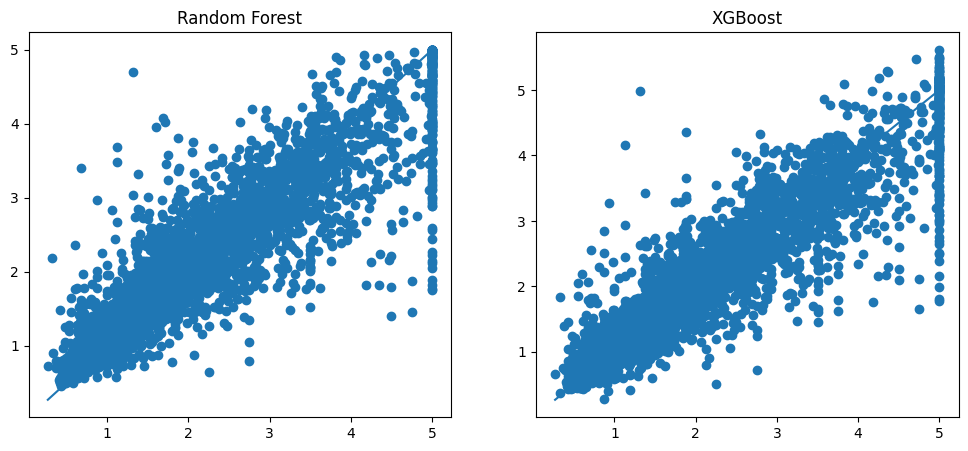

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_te, rf_pred)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()])
plt.title("Random Forest")

plt.subplot(1,2,2)
plt.scatter(y_te, xgb_pred)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()])
plt.title("XGBoost")

plt.show()

Graf prikazuje odnos između stvarnih i predviđenih vrijednosti. Što su točke bliže dijagonali, to je model precizniji.

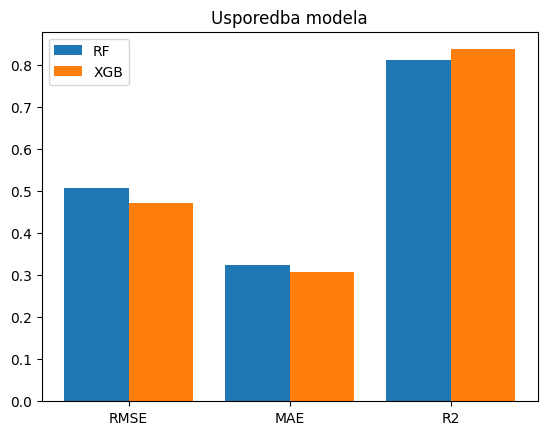

In [9]:
rf_rmse = np.sqrt(mean_squared_error(y_te, rf_pred))
xgb_rmse = np.sqrt(mean_squared_error(y_te, xgb_pred))

rf_mae = mean_absolute_error(y_te, rf_pred)
xgb_mae = mean_absolute_error(y_te, xgb_pred)

rf_r2 = r2_score(y_te, rf_pred)
xgb_r2 = r2_score(y_te, xgb_pred)

labels = ["RMSE", "MAE", "R2"]
rf_vals = [rf_rmse, rf_mae, rf_r2]
xgb_vals = [xgb_rmse, xgb_mae, xgb_r2]

x = np.arange(len(labels))

plt.bar(x-0.2, rf_vals, width=0.4, label="RF")
plt.bar(x+0.2, xgb_vals, width=0.4, label="XGB")

plt.xticks(x, labels)
plt.legend()
plt.title("Usporedba modela")
plt.show()

Na grafu uspoređujemo performanse oba modela. Model s manjim RMSE i MAE te većim R² smatra se boljim.

U ovom radu uspoređena su dva modela: Random Forest i XGBoost za predviđanje cijena kuća.
Rezultati pokazuju da XGBoost model ostvaruje nešto bolje performanse u odnosu na Random Forest, što se vidi kroz niže vrijednosti RMSE i MAE te viši R².
Vizualizacije također potvrđuju da XGBoost daje preciznija predviđanja jer su njegove vrijednosti bliže stvarnim podacima.
Oba modela daju dobre rezultate, ali XGBoost pokazuje veću sposobnost generalizacije i bolje hvata složenije odnose u podacima.